In [1]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration
from torch.optim import AdamW
from torch.amp import autocast, GradScaler
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"
print(f"Using device: {device}")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True

Using device: cuda


In [2]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
HF_TOKEN = user_secrets.get_secret("HF-TOKEN")

In [3]:
import os
os.environ["HF_TOKEN"] = HF_TOKEN

In [4]:
from datasets import load_dataset
import glob
import hashlib
from collections import defaultdict
import os

# Point the Hugging Face cache to Kaggle's writable working directory
os.environ["HF_DATASETS_CACHE"] = "/kaggle/working/hf_cache"

# Get all file paths
train_files = sorted(glob.glob("/kaggle/input/datasets/chaitanyadhanai/potato-tuber-disease-dataset-v77/*train*.arrow"))
test_files  = sorted(glob.glob("/kaggle/input/datasets/chaitanyadhanai/potato-tuber-disease-dataset-v77/*test*.arrow"))
val_files   = sorted(glob.glob("/kaggle/input/datasets/chaitanyadhanai/potato-tuber-disease-dataset-v77/*validation*.arrow"))

all_files = train_files + val_files + test_files

# Load everything directly into a single dataset using the "arrow" loader.
# This prevents tying the dataset to the read-only /kaggle/input/ directory.
full_ds = load_dataset("arrow", data_files={"all_data": all_files}, split="all_data")
print(len(full_ds))

Resolving data files:   0%|          | 0/57 [00:00<?, ?it/s]

Generating all_data split: 0 examples [00:00, ? examples/s]

Loading dataset shards:   0%|          | 0/56 [00:00<?, ?it/s]

40080


In [5]:
from datasets import Dataset
def build_groups(ds):

    def image_hash(img_dict):

        return hashlib.md5(img_dict["bytes"]).hexdigest()

    

    groups = defaultdict(list)

    

    for idx, ex in enumerate(ds):

        h = image_hash(ex["image"])

        groups[h].append(idx)

    

    return list(groups.values())



all_groups = build_groups(full_ds)
def create_generator(ds, groups):
    def gen():
        for group in groups:
            # Get the image from the first index in the group
            first_idx = group[0]
            image_data = ds[first_idx]["image"]
            
            # Collect all captions associated with this image
            caps = [ds[idx]["caption"] for idx in group]
            
            # Yield one single combined row at a time
            yield {
                "image": image_data,
                "captions": caps
            }
    return gen

# 3. Process it using from_generator
# This streams the data directly to disk/Arrow instead of holding it in RAM
processed_full_ds = Dataset.from_generator(create_generator(full_ds, all_groups))

print(f"New dataset size: {len(processed_full_ds)}")

Generating train split: 0 examples [00:00, ? examples/s]

New dataset size: 6764


In [6]:
print(processed_full_ds)

Dataset({
    features: ['image', 'captions'],
    num_rows: 6764
})


In [7]:
from datasets import DatasetDict

# 1. Initial Split: 90% for training, 10% reserved for validation/testing
initial_split = processed_full_ds.train_test_split(test_size=0.2, seed=42)

# 2. Final Split: Divide the reserved 10% exactly in half (10% Val, 10% Test)
val_test_split = initial_split['test'].train_test_split(test_size=0.5, seed=42)

# 3. Assign to your designated variables
train_groups = initial_split['train']
val_groups = val_test_split['train']
test_groups = val_test_split['test']

# 
# This makes it very easy to use .save_to_disk() or .push_to_hub() later
final_dataset = DatasetDict({
    'train': train_groups,
    'validation': val_groups,
    'test': test_groups
})

# Quick verification print
print(f"Train: {len(train_groups)} | Val: {len(val_groups)} | Test: {len(test_groups)}")

Train: 5411 | Val: 676 | Test: 677


In [8]:
# Grab the "captions" column first, then slice it, then get the lengths
lengths = [len(caps) for caps in train_groups["captions"][:13]]
print(lengths)

[5, 5, 5, 5, 10, 5, 5, 5, 10, 5, 5, 10, 5]


Total captions for this image: 10
------------------------------
Caption 1: A whole potato tuber showing mild soft rot symptoms on the outer surface.
Caption 2: A whole potato tuber showing mild soft rot symptoms on the outer surface.
Caption 3: A whole potato tuber affected by mild surface softening due to soft rot.
Caption 4: A whole potato tuber sample with mild external softening associated with soft rot disease.
Caption 5: A whole potato tuber exhibiting mild soft, water-soaked patches on the peel.
Caption 6: A whole potato tuber affected by mild surface softening due to soft rot.
Caption 7: A whole potato tuber displaying mild moist, slightly collapsed areas characteristic of soft rot.
Caption 8: A whole potato tuber displaying mild moist, slightly collapsed areas characteristic of soft rot.
Caption 9: A whole potato tuber sample with mild external softening associated with soft rot disease.
Caption 10: A whole potato tuber exhibiting mild soft, water-soaked patches on the peel.


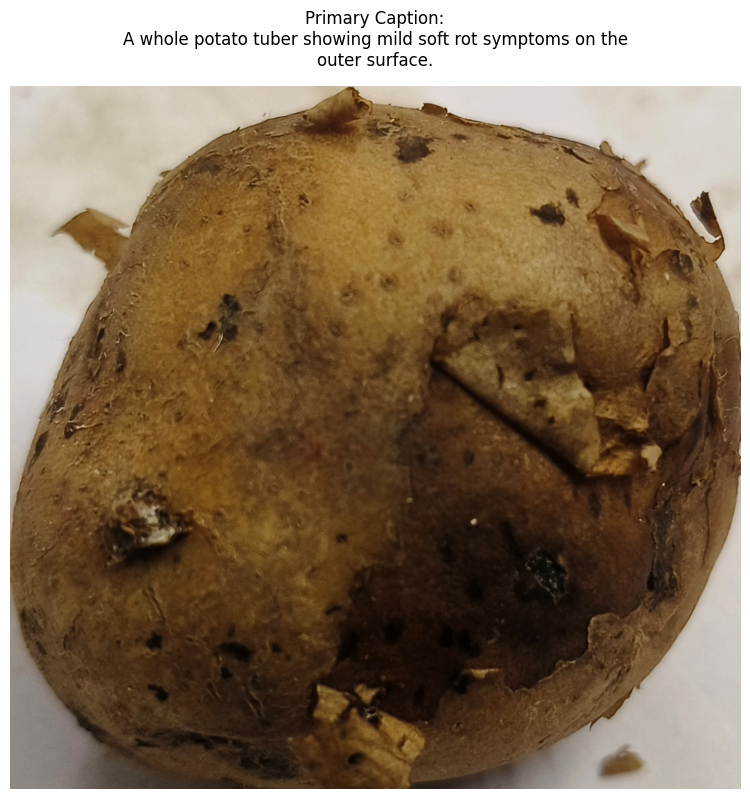

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import io
import textwrap

# 1. Grab a sample from your new test split
# (You can change this to train_groups or val_groups to check those too)
sample = test_groups[110]

# 2. Extract and format the list of captions
caption_list = sample["captions"]

print(f"Total captions for this image: {len(caption_list)}")
print("-" * 30)

# Print all captions nicely to the console
for i, cap in enumerate(caption_list, 1):
    print(f"Caption {i}: {cap}")

# 3. Extract and decode the image
image_data = sample["image"]

if isinstance(image_data, dict) and "bytes" in image_data:
    img = Image.open(io.BytesIO(image_data["bytes"]))
else:
    img = image_data

# 4. Plot it
plt.figure(figsize=(8, 8))
plt.imshow(img)

# Use the first caption as the title, wrapping it so it fits on screen
title_text = "\n".join(textwrap.wrap(caption_list[0], width=60))
plt.title(f"Primary Caption:\n{title_text}", fontsize=12, pad=15)

plt.axis("off") 
plt.tight_layout()
plt.show()

In [ ]:
# train_groups = [g for g in train_groups if 4 <= len(g) <= 8]
# val_groups   = [g for g in val_groups if 4 <= len(g) <= 8]
# test_groups  = [g for g in test_groups if 4 <= len(g) <= 8]

In [10]:
# --- Configuration ---
MODEL_NAME = "Salesforce/blip-image-captioning-base"

EPOCHS = 8
BATCH_SIZE = 16
LEARNING_RATE = 1e-5
MAX_LENGTH = 64
NUM_WORKERS = 4
pin_memory = True
SEED = 41

In [11]:
from transformers import AutoProcessor, AutoModelForVisualQuestionAnswering
processor = AutoProcessor.from_pretrained(MODEL_NAME)
print("Processor loaded.")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Processor loaded.


In [12]:
model = BlipForConditionalGeneration.from_pretrained(MODEL_NAME)
model.to(device)
#trying gradient checkpointing to fit larger effective batch size on GPU
# model.gradient_checkpointing_enable()
model.config.use_cache = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable parameters: 247,444,600 / 247,444,600 (100.0%)


In [13]:
import random
import io
from PIL import Image

# Helper to reliably decode images
def load_clean_image(img_data):
    if isinstance(img_data, dict) and "bytes" in img_data:
        return Image.open(io.BytesIO(img_data["bytes"])).convert("RGB")
    return img_data.convert("RGB")

params = [p for p in model.parameters() if p.requires_grad]
optimizer = AdamW(params, lr=LEARNING_RATE)
autocast_ctx = torch.autocast(device_type="cuda", dtype=torch.float16)
accum_steps = 2
scaler = GradScaler(enabled=use_amp)

BATCH_SIZE_GROUPS = 8  

for epoch in range(EPOCHS):
    model.train()
    epoch_train_loss = 0.0
    optimizer.zero_grad(set_to_none=True)

    # Optional but recommended: Shuffle the training data at the start of each epoch
    train_ds_shuffled = train_groups.shuffle(seed=epoch)
    
    # Calculate total batches
    num_batches = (len(train_ds_shuffled) + BATCH_SIZE_GROUPS - 1) // BATCH_SIZE_GROUPS

    for batch_idx in range(num_batches):
        # 1. Slice the batch directly from the dataset
        start_idx = batch_idx * BATCH_SIZE_GROUPS
        end_idx = start_idx + BATCH_SIZE_GROUPS
        batch_data = train_ds_shuffled[start_idx:end_idx]

        images = []
        captions = []

        # 2. Extract images and pick one random caption per image for this epoch
        for img_data, caps_list in zip(batch_data["image"], batch_data["captions"]):
            images.append(load_clean_image(img_data))
            captions.append(random.choice(caps_list))

        # ---- batch image processing ----
        pixel_values = processor.image_processor(
            images=images,
            return_tensors="pt"
        )["pixel_values"].to(device)

        # ---- batch tokenization ----
        tokenized = processor.tokenizer(
            captions,
            padding=True,              
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt"
        )

        input_ids = tokenized["input_ids"].to(device)
        attention_mask = tokenized["attention_mask"].to(device) 

        labels = input_ids.clone()
        labels[labels == processor.tokenizer.pad_token_id] = -100

        # ---- forward ----
        with autocast_ctx:
            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask, 
                labels=labels
            )
            raw_loss = outputs.loss
            loss = raw_loss / accum_steps

        scaler.scale(loss).backward()

        if (batch_idx + 1) % accum_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        epoch_train_loss += raw_loss.detach().item()

    # Catch any remaining gradients at the end of the epoch
    if num_batches % accum_steps != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

    avg_train_loss = epoch_train_loss / num_batches

    # ==========================================
    # VALIDATION LOOP
    # ==========================================
    model.eval()
    epoch_val_loss = 0.0
    
    with torch.inference_mode():
        # Iterate sequentially through the validation dataset
        for i in range(len(val_groups)):
            example = val_groups[i] 
            
            image = load_clean_image(example["image"])  
    
            pixel_values = processor.image_processor(
                image, return_tensors="pt"
            )["pixel_values"].to(device)
    
            # Compute loss against the FIRST caption consistently to keep validation stable
            caption = example["captions"][0]
    
            tokenized = processor.tokenizer(
                caption,
                truncation=True,
                padding=True,
                max_length=MAX_LENGTH,
                return_tensors="pt"
            )
            
            input_ids = tokenized["input_ids"].to(device) 
            attention_mask = tokenized["attention_mask"].to(device)
            labels = input_ids.clone() 
            labels[labels == processor.tokenizer.pad_token_id] = -100
    
            with autocast_ctx:
                outputs = model(
                    pixel_values=pixel_values,
                    input_ids=input_ids,           
                    attention_mask=attention_mask, 
                    labels=labels
                )
    
            epoch_val_loss += outputs.loss.item()
    
    avg_val_loss = epoch_val_loss / len(val_groups)
    
    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Epoch 1 | Train Loss: 1.3840 | Val Loss: 0.3985
Epoch 2 | Train Loss: 0.2648 | Val Loss: 0.2040
Epoch 3 | Train Loss: 0.1850 | Val Loss: 0.1773
Epoch 4 | Train Loss: 0.1643 | Val Loss: 0.1576
Epoch 5 | Train Loss: 0.1534 | Val Loss: 0.1621
Epoch 6 | Train Loss: 0.1433 | Val Loss: 0.1497
Epoch 7 | Train Loss: 0.1355 | Val Loss: 0.1505
Epoch 8 | Train Loss: 0.1313 | Val Loss: 0.1521
Epoch 9 | Train Loss: 0.1244 | Val Loss: 0.1567
Epoch 10 | Train Loss: 0.1177 | Val Loss: 0.1508


In [14]:
%%capture
!pip install pycocoevalcap evaluate rouge_score
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from pycocoevalcap.cider.cider import Cider
import nltk
import evaluate

try:

    nltk.data.find("tokenizers/punkt")

except LookupError:

    nltk.download("punkt")
    # Load standardized Hugging Face metrics
model.eval()
bleu_metric = evaluate.load("bleu")
meteor_metric = evaluate.load("meteor")
rouge_metric = evaluate.load("rouge")

In [15]:
import io
from PIL import Image
import torch
# Assuming Cider, processor, model, MAX_LENGTH, and device are already defined

def load_clean_image(img_data):
    if isinstance(img_data, dict) and "bytes" in img_data:
        return Image.open(io.BytesIO(img_data["bytes"])).convert("RGB")
    return img_data.convert("RGB")

# Initialize CIDEr
cider_scorer = Cider()
model.eval()

predictions = []
references = []
gts = {}
res = {}

idx = 0  # Global index for CIDEr formatting
EVAL_BATCH_SIZE = 8 # Adjust based on your VRAM

print("Starting batched evaluation...")

# Calculate total batches based on the length of your clean test dataset
num_batches = (len(test_groups) + EVAL_BATCH_SIZE - 1) // EVAL_BATCH_SIZE

with torch.inference_mode():
    for batch_idx in range(num_batches):
        
        # 1. Slice the batch directly from the dataset
        start_idx = batch_idx * EVAL_BATCH_SIZE
        end_idx = start_idx + EVAL_BATCH_SIZE
        batch_data = test_groups[start_idx:end_idx]
        
        images = []
        batch_refs = []

        # 2. Gather images and references for the current batch
        for img_data, caps_list in zip(batch_data["image"], batch_data["captions"]):
            # Safely decode the image
            image = load_clean_image(img_data)
            images.append(image)

            # Clean all reference captions for this image
            clean_refs = [str(r).strip().lower() for r in caps_list]
            batch_refs.append(clean_refs)

        # 3. Process the batch of images at once
        pixel_values = processor.image_processor(
            images, 
            return_tensors="pt"
        )["pixel_values"].to(model.device)

        # 4. Generate captions for the entire batch
        generated_ids = model.generate(
            pixel_values,
            max_length=MAX_LENGTH,
            num_beams=5,
            length_penalty=1.0,
            early_stopping=True,
            no_repeat_ngram_size=2,
            repetition_penalty=1.2
        )

        # 5. Decode the batch of predictions
        preds = processor.batch_decode(
            generated_ids, skip_special_tokens=True
        )

        # 6. Store predictions and references in CIDEr format
        for pred, clean_refs in zip(preds, batch_refs):
            clean_pred = pred.strip().lower()

            predictions.append(clean_pred)
            references.append(clean_refs)

            # CIDEr dictionary format requires lists
            res[idx] = [clean_pred]
            gts[idx] = clean_refs
            idx += 1

print("Generation complete. Computing metrics...")

# Optional: Actually run the CIDEr computation if you haven't already!
# score, scores = cider_scorer.compute_score(gts, res)
# print(f"CIDEr Score: {score:.4f}")

Starting batched evaluation...
Generation complete. Computing metrics...


In [16]:
bleu1 = bleu_metric.compute(
    predictions=predictions,
    references=references,
    max_order=1,
    smooth=True
)

bleu2 = bleu_metric.compute(
    predictions=predictions,
    references=references,
    max_order=2,
    smooth=True
)

bleu3 = bleu_metric.compute(
    predictions=predictions,
    references=references,
    max_order=3,
    smooth=True
)

bleu4 = bleu_metric.compute(
    predictions=predictions,
    references=references,
    max_order=4,
    smooth=True
)

meteor_result = meteor_metric.compute(
    predictions=predictions,
    references=[refs[0] for refs in references]
)

rouge_result = rouge_metric.compute(
    predictions=predictions,
    references=[refs[0] for refs in references]
)
cider_score, _ = cider_scorer.compute_score(gts, res)
# Print results
print("Testing Caption Metrics")
print(f"BLEU-1: {bleu1['bleu']:.4f}")
print(f"BLEU-2: {bleu2['bleu']:.4f}")
print(f"BLEU-3: {bleu3['bleu']:.4f}")
print(f"BLEU-4: {bleu4['bleu']:.4f}")
print(f"METEOR: {meteor_result['meteor']:.4f}")
print(f"CIDEr: {cider_score:.4f}")
print(f"ROUGE-L: {rouge_result['rougeL']:.4f}")

Testing Caption Metrics
BLEU-1: 0.8240
BLEU-2: 0.7499
BLEU-3: 0.7011
BLEU-4: 0.6658
METEOR: 0.3719
CIDEr: 1.1419
ROUGE-L: 0.3486


In [17]:
num_samples = 5

for i in range(num_samples):
    print("="*60)
    print(f"Prediction:\n{predictions[i]}")
    print("-"*60)
    print("References:")
    for ref in references[i]:
        print(f"- {ref}")

Prediction:
a whole potato tuber displaying moderate superficial corky eruptions characteristic of common scab.
------------------------------------------------------------
References:
- tuber showing initial lesion development with small, slightly sunken brown spots on the periderm.
- represents the mild severity class of dry rot infection, indicating early pathological progression.
- a whole potato tuber exhibiting early-stage dry rot symptoms caused by fusarium spp., characterized by localized and mild pathological changes.
- presence of minor surface discoloration with limited tissue degradation, without extensive spread across the tuber.
- morphologically near-intact potato tuber with slight textural irregularities and early signs of dehydration or shriveling.
Prediction:
a cut potato tuber displaying mild green discoloration on outer flesh.
------------------------------------------------------------
References:
- a cut-section of a potato tuber showing mild fusarium dry rot infe